In [1]:
import pandas as pd
import sqlite3

con = sqlite3.connect("../data/checking-logs.sqlite")

## Load commits (users only)

In [2]:
q = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%';
"""
df = pd.io.sql.read_sql(q, con, parse_dates=["timestamp"])
df.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


## Extract hour and weekday/weekend

In [3]:
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.weekday  # Mon=0 ... Sun=6
df["is_weekend"] = df["weekday"] >= 5
df[["timestamp", "hour", "weekday", "is_weekend"]].head()

,timestamp,hour,weekday,is_weekend
0,2020-04-17 05:19:02.744528,5,4,False
1,2020-04-17 05:22:35.249331,5,4,False
2,2020-04-17 05:22:45.549397,5,4,False
3,2020-04-17 05:34:14.691200,5,4,False
4,2020-04-17 05:34:24.422370,5,4,False


## Average commits per hour (weekdays)

In [5]:
weekday_hours = (
    df[~df["is_weekend"]]
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

# average per weekday (divide by number of unique weekday dates)
weekday_dates = df[~df["is_weekend"]]["timestamp"].dt.date.nunique()
weekday_avg = weekday_hours / weekday_dates
weekday_avg.head()

hour
0    0.24
1    0.00
2    0.00
3    0.08
4    0.00
dtype: float64

## Plot weekdays

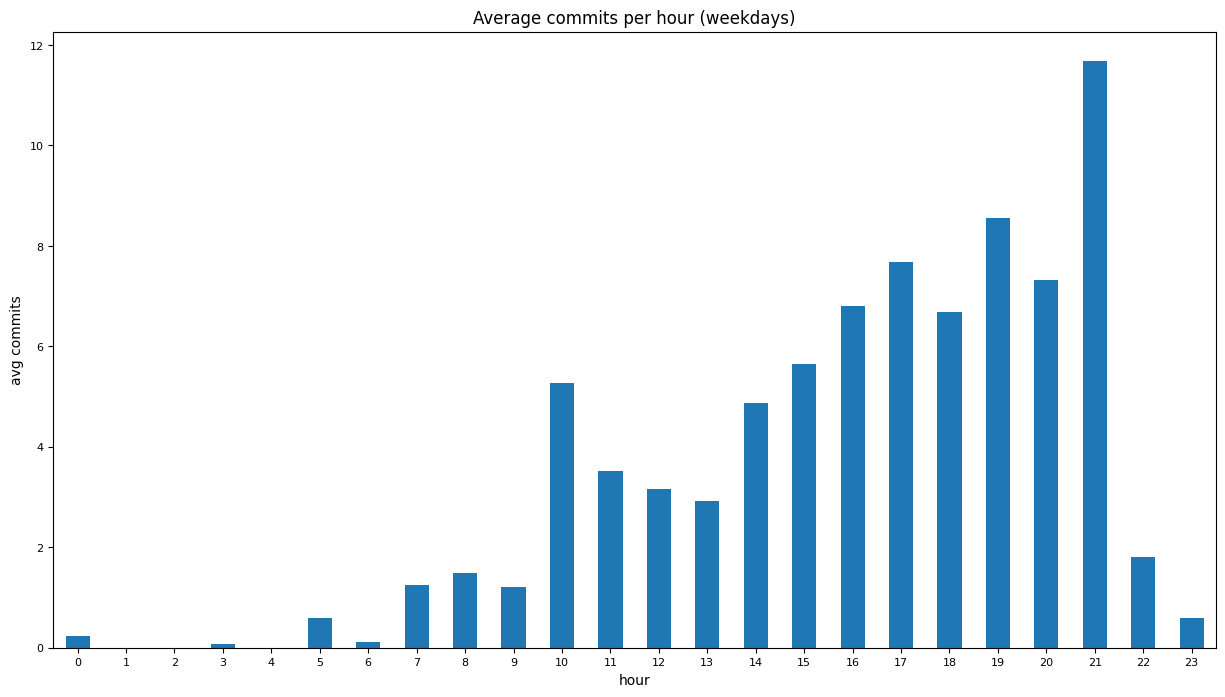

In [6]:
ax = weekday_avg.plot(kind="bar", figsize=(15, 8), fontsize=8, title="Average commits per hour (weekdays)")
ax.set_xlabel("hour")
ax.set_ylabel("avg commits")
ax.tick_params(axis="x", rotation=0)

## Average commits per hour (weekends)

In [7]:
weekend_hours = (
    df[df["is_weekend"]]
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

weekend_dates = df[df["is_weekend"]]["timestamp"].dt.date.nunique()
weekend_avg = weekend_hours / weekend_dates
weekend_avg.head()

hour
0    0.6
1    0.6
2    0.0
3    0.1
4    0.0
dtype: float64

## Plot weekends

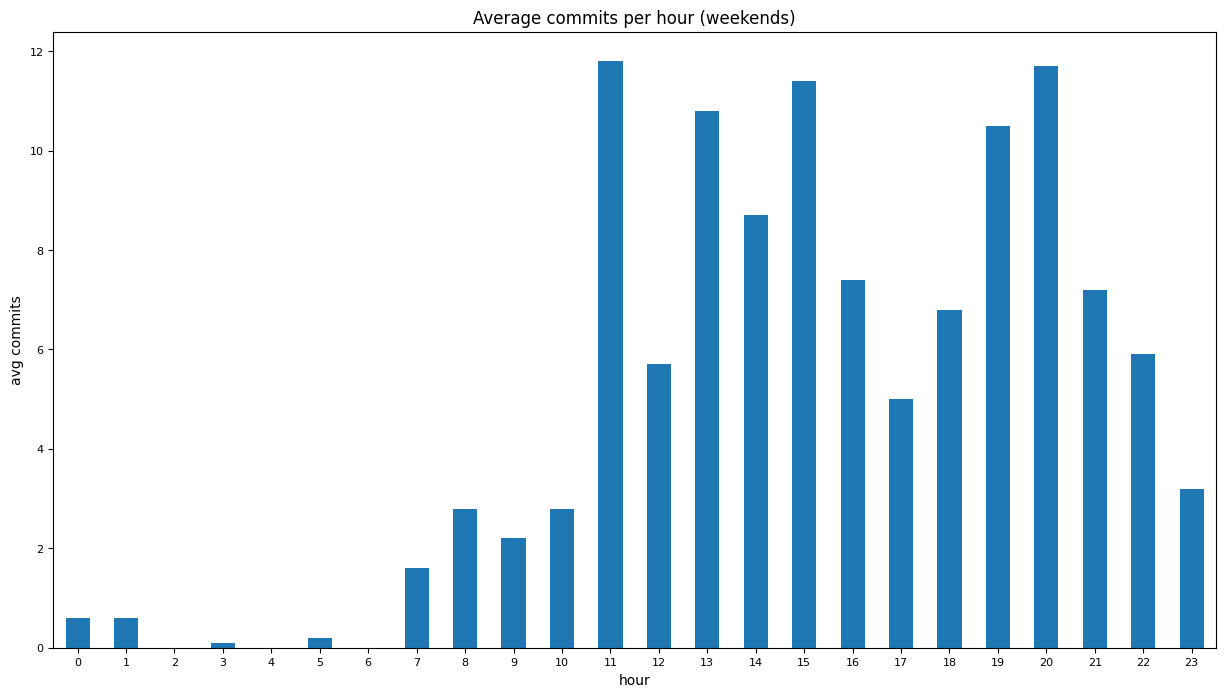

In [8]:
ax = weekend_avg.plot(kind="bar", figsize=(15, 8), fontsize=8, title="Average commits per hour (weekends)")
ax.set_xlabel("hour")
ax.set_ylabel("avg commits")
ax.tick_params(axis="x", rotation=0)

In [9]:
con.close()